In [10]:
# Install dependencies (run once on Colab)
!pip install -q diffusers accelerate


# Notebook 1 — Diffusion Models from Scratch

> **Reference:** Ho, Jain & Abbeel — *Denoising Diffusion Probabilistic Models* (NeurIPS 2020)

## Generative AI

Generative AI is a class of machine learning models that can generate new content
(such as images, text, video...) by learning patterns from existing data.
To do it, we learn the **probability distribution** of the data to produce meaningful
new images. This can be:
- **Explicitly learned:** the task of the NN is to learn $p(x)$ directly
  (e.g. VAEs, normalizing flows, diffusion models)
- **Implicitly learned:** the model learns to produce realistic samples without ever
  computing $p(x)$ (e.g. GANs, where a generator fools a discriminator)

For example: if we train on photos of human faces, the model should learn that images
with two eyes, a nose, and a mouth arranged in the usual way are very likely — while
a random soup of pixels, or a face with three eyes, is essentially impossible. A good
generative model captures these regularities and can then *sample* new, never-seen
faces that look perfectly natural.

In [11]:
!pip install -q diffusers

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
seed = 123
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


---
## 1. The Forward Process (Diffusion)

A DDPM is built around two processes. The first is the **forward process**: gradually
corrupt an image $x_0$ through a chain of Gaussian noise additions. This is done for every pixel and every color channel. After
 many steps, the image is destroyed. To produce $x_1$ for example
$$x_1​=\sqrt{1−β_1}​​x_{0​}+\sqrt{β_1}​​ϵ_1​$$
where 
* $​ϵ_1 \sim N(0, I)$ is a Gaussian noise sample 
* $β_1$ is how much noise we add

they contribute as a random (Brownian) motion contribution
* $\sqrt{1−β_1}$ is to keep the image normalizated

they contribute as a counteracting drift to the random motion.

Then we use $x_1$ to get $x_2$, $x_2$ to get $x_3$ etc.

We **know the formula of every intermediate step**: we can directly compute $x_t$ as a function of
$x_0$, $\beta$ and $\epsilon \sim N(0, I)$
$$x_t​=\sqrt{\bar{α}_t​}​x_0​+\sqrt{1−\bar{α}_t}​​ϵ$$
$$\bar{α}_t = \prod_i (1 - \beta_i)$$

In [13]:
T_STEPS = 1000    # nr of noising steps

# for example we can take constant beta
betas = torch.ones(T_STEPS).to(device) * 0.001

alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

In [14]:
# Download dataset (DeepLearningAI short course)
import os
from torch.utils.data import Dataset

SPRITES_URL = "https://github.com/Ryota-Kawamura/How-Diffusion-Models-Work/raw/main/sprites_1788_16x16.npy"
SPRITES_PATH = "./data/dataset/sprites_1788_16x16.npy"
IMG_SIZE = 16  # 16 x 16 images
IMG_CHANNELS = 3  # RGB

if not os.path.exists(SPRITES_PATH):
    os.makedirs("./data", exist_ok=True)
    os.makedirs("./data/dataset", exist_ok=True)
    os.makedirs("./data/model", exist_ok=True)
    print("Downloading sprites dataset...")
    torch.hub.download_url_to_file(SPRITES_URL, SPRITES_PATH)


class SpritesDataset(Dataset):

    def __init__(self, path):
        data = np.load(path)  
        # (N, 16, 16, 3) uint8 in [0, 255]
        # Deduplicate: the file repeats 1788 sprites 50 times
        data = data[: len(data) // 50]
        # To float tensor in [-1, 1], channels-first
        self.images = torch.from_numpy(data).float() / 255.0
        self.images = (self.images - 0.5) * 2  # [-1, 1]
        self.images = self.images.permute(0, 3, 1, 2)  # (N, 3, 16, 16)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], 0  # dummy label for compatibility


dataset = SpritesDataset(SPRITES_PATH)
print(f"Sprites dataset: {len(dataset)} images, shape {dataset[0][0].shape}")

100%|██████████| 65.5M/65.5M [00:01<00:00, 62.7MB/s]


Sprites dataset: 1788 images, shape torch.Size([3, 16, 16])


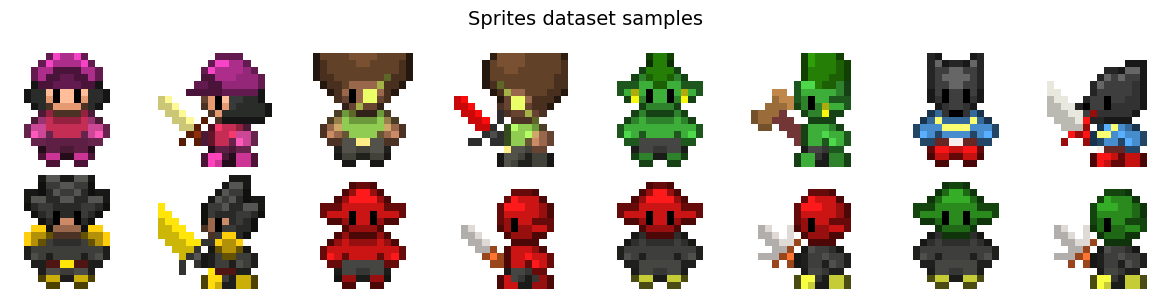

In [15]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    # back to [0, 1] for visualization purposes
    img = dataset[i][0] * 0.5 + 0.5  
    ax.imshow(img.permute(1, 2, 0).numpy(), interpolation="nearest")
    ax.axis("off")
plt.suptitle("Sprites dataset samples", fontsize=14)
plt.tight_layout()
plt.show()

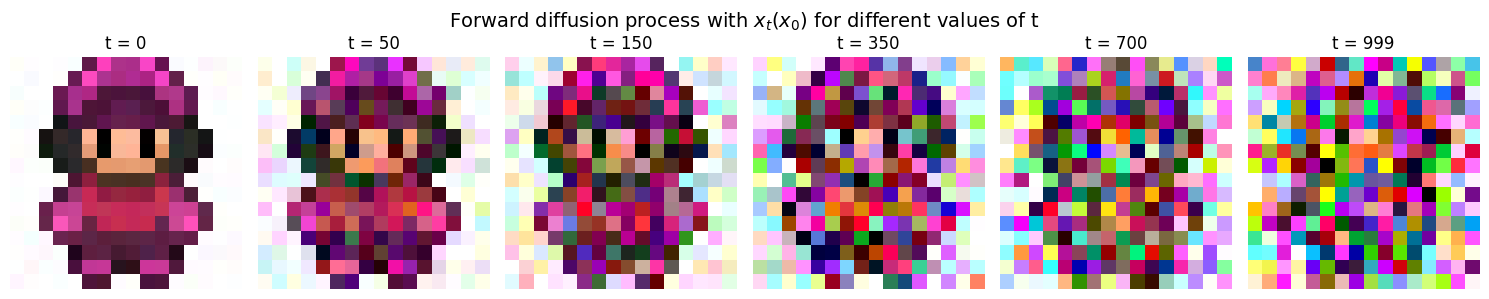

In [16]:
def forward_sample(x0, t, noise=None):
    """Sample x at step t from image x0"""
    if noise is None:
        noise = torch.randn_like(x0)
    # broadcast over C, H, W
    ab = alpha_bar[t].view(-1, 1, 1, 1)
    return torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise, noise
  
sample_img = dataset[0][0].unsqueeze(0).to(device)  # (1, 3, 16, 16)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
timesteps = [0, 50, 150, 350, 700, 999]
for ax, ts in zip(axes, timesteps):
    t_tensor = torch.tensor([ts], device=device)
    noisy, _ = forward_sample(sample_img, t_tensor)
    img = noisy[0].cpu().clamp(-1, 1) * 0.5 + 0.5  # back to [0,1]
    ax.imshow(img.permute(1, 2, 0).numpy(), interpolation="nearest")
    ax.set_title(f"t = {ts}")
    ax.axis("off")
plt.suptitle("Forward diffusion process with $x_t(x_0)$ for different values of t", fontsize=14)
plt.tight_layout()
plt.show()

Using linear schedule


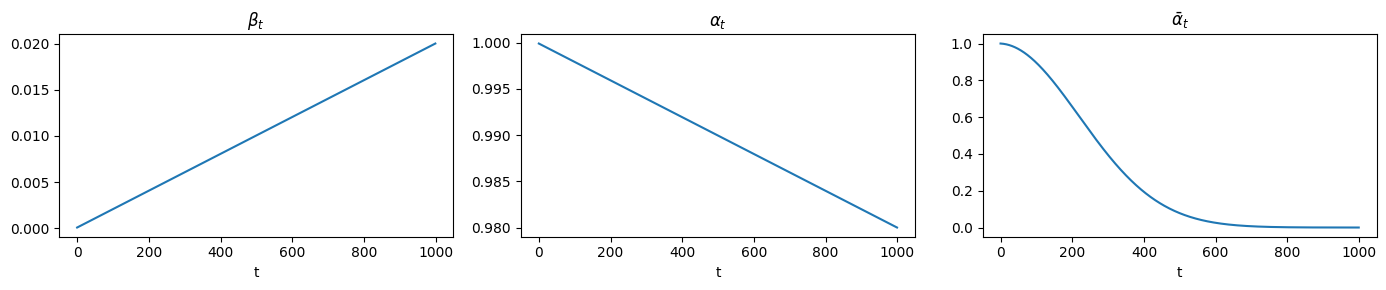

In [17]:
# Choose schedule: "linear" or "cosine"
SCHEDULE = "linear"

#cosine schedule for example, to retain signal longer
def cosine_beta_schedule(timesteps, s=0.008):
    steps = torch.arange(timesteps + 1, dtype=torch.float64)
    f_t = torch.cos(((steps / timesteps) + s) / (1 + s) * (torch.pi / 2)) ** 2
    alpha_bar_cos = f_t / f_t[0]
    # Derive betas from alpha_bar: beta_t = 1 - alpha_bar_t / alpha_bar_{t-1}
    betas = 1 - (alpha_bar_cos[1:] / alpha_bar_cos[:-1])
    return torch.clip(betas, 0.0001, 0.9999).float()


# Build the noise schedule
if SCHEDULE == "linear":
    betas = torch.linspace(1e-4, 0.02, T_STEPS).to(device)
elif SCHEDULE == "cosine":
    betas = cosine_beta_schedule(T_STEPS).to(device)
else:
    raise ValueError(f"Unknown schedule: {SCHEDULE}. Use 'linear' or 'cosine'.")

alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

print(f"Using {SCHEDULE} schedule")

# plot betas and alpha_bar for the chosen schedule
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 3))

ax1.plot(betas.cpu())
ax1.set_title(f"$\\beta_t$")
ax1.set_xlabel('t')

ax2.plot(alphas.cpu())
ax2.set_title(f"$\\alpha_t$")
ax2.set_xlabel('t')

ax3.plot(alpha_bar.cpu())
ax3.set_title(f"$\\bar{{\\alpha}}_t$")
ax3.set_xlabel('t')

plt.tight_layout()
plt.show()

### Closed-form shortcut: one jump vs many steps

Let's verify that doing $x_t(x_0)$ is the same as $x_0 \rightarrow x_1 \rightarrow x_2\dots$

In [18]:
# We run many trials and compare per-pixel mean and variance.

N_TRIALS = 5000

target_t = 200
ab = alpha_bar[target_t]

step_samples = torch.zeros(N_TRIALS, *sample_img.shape[1:], device=device)
direct_samples = torch.zeros(N_TRIALS, *sample_img.shape[1:], device=device)

for i in range(N_TRIALS):
    # Step-by-step
    x = sample_img.clone()
    for s in range(target_t):
        x = torch.sqrt(1 - betas[s]) * x + torch.sqrt(betas[s]) * torch.randn_like(x)
    step_samples[i] = x[0]

    # Closed-form (single noise draw)
    eps = torch.randn_like(sample_img)
    x_d = torch.sqrt(ab) * sample_img + torch.sqrt(1 - ab) * eps
    direct_samples[i] = x_d[0]

# Compare statistics
# Mean on each pixel across all images, dimension is (3, 16, 16)
step_mean = step_samples.mean(0).cpu()
direct_mean = direct_samples.mean(0).cpu()
step_var = step_samples.var(0).cpu()
direct_var = direct_samples.var(0).cpu()

print(f"Step-by-step mean pixel:   {step_mean.mean().item():.4f}")
print(f"Closed-form mean pixel:    {direct_mean.mean().item():.4f}")
print(f"Step-by-step variance:     {step_var.mean().item():.4f}")
print(f"Closed-form variance:      {direct_var.mean().item():.4f}")

Step-by-step mean pixel:   0.1750
Closed-form mean pixel:    0.1746
Step-by-step variance:     0.3412
Closed-form variance:      0.3438


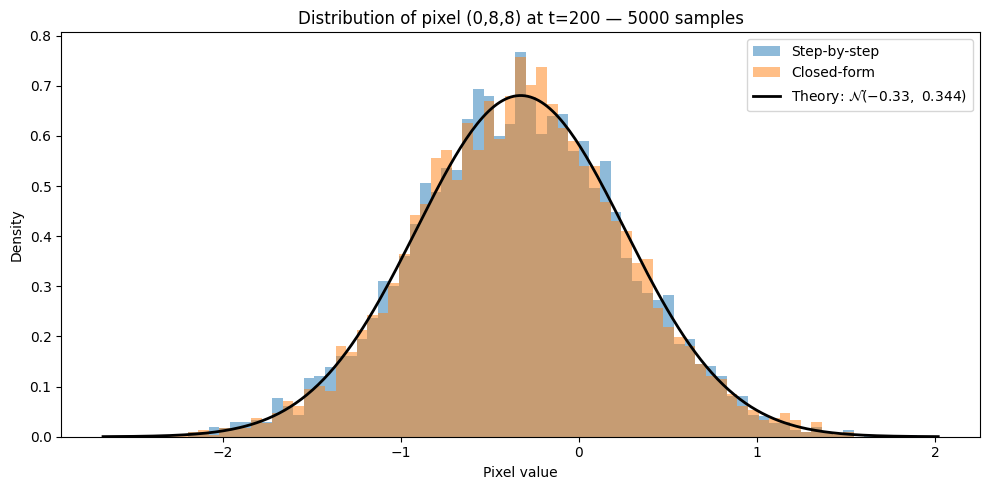

In [19]:
# Visualise the comparison: overlaid histograms for a single pixel
# Pick a pixel near the centre of the image and plot the empirical distribution
# from both methods against the theoretical Gaussian.

# sample pixel
px_c, px_h, px_w = 0, IMG_SIZE // 2, IMG_SIZE // 2  # channel 0, centre pixel

step_pixel_vals = step_samples[:, px_c, px_h, px_w].cpu().numpy()
direct_pixel_vals = direct_samples[:, px_c, px_h, px_w].cpu().numpy()

#   x_t = mean x_0 + sqrt(var)*epsilon
#   so the theoretical distribution for this pixel:
#   mean = sqrt(alpha_bar_t) * x0_pixel
#   var  = 1 - alpha_bar_t
x0_pixel = sample_img[0, px_c, px_h, px_w].cpu().item()
theo_mean = np.sqrt(ab.cpu().item()) * x0_pixel
theo_std = np.sqrt(1 - ab.cpu().item())

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(theo_mean - 4 * theo_std, theo_mean + 4 * theo_std, 80)

ax.hist(step_pixel_vals, bins=bins, alpha=0.5, density=True, label="Step-by-step")
ax.hist(direct_pixel_vals, bins=bins, alpha=0.5, density=True, label="Closed-form")

# Overlay theoretical Gaussian
x_range = np.linspace(bins[0], bins[-1], 300)
gaussian_pdf = (1 / (theo_std * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_range - theo_mean) / theo_std) ** 2
)
ax.plot(x_range, gaussian_pdf, "k-", lw=2,
        label=f"Theory: $\\mathcal{{N}}({theo_mean:.2f},\\ {theo_std**2:.3f})$")

ax.set_xlabel("Pixel value")
ax.set_ylabel("Density")
ax.set_title(f"Distribution of pixel ({px_c},{px_h},{px_w}) at t={target_t} — {N_TRIALS} samples")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Training
In training we try to invert the process from the corrupted image. Since we have that
$$x_t​=\sqrt{\bar{α}_t​}​x_0​+\sqrt{1−\bar{α}_t}​​ϵ$$
from $x_t$ we can predict ​ϵ and use the formula to compute $x_0$. While corrupting the image was like encoding, this step is like decoding from a Gaussian noise latent space. In this way, from noise, we can predict $x_0$ and so actually generate
images from the Gaussian noise.

Architecture: the original paper uses a UNet. Main blocks:
* phase 1:
    * Res block (IN + CONV(IN))
    * Attention
    * Downsampling
* phase 2: UP(IN)
    * Res block (IN + CONV(IN))
    * Attention
    * Upsampling

In [20]:
from diffusers import UNet2DModel
def make_unet():
    """Create a small U-Net sized for 16x16 sprites."""
    return UNet2DModel(
        sample_size=IMG_SIZE,
        in_channels=IMG_CHANNELS,
        out_channels=IMG_CHANNELS,
        layers_per_block=2,
        block_out_channels=(64, 128, 256),
        down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
        up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
    )

model = make_unet().to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

/home/svicentini/anaconda3/envs/double_app_traffic/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Parameters: 16,056,451


**Objective**

The simplified objective (Ho et al. 2020):

$\mathcal{L} = \mathbb{E}_{t,\, x_0,\, \varepsilon}\left[\| \varepsilon - \varepsilon_\theta(x_t, t) \|^2\right]$

**Steps**

Each step: sample step T, corrupt the image, ask the network to predict the noise,
minimise MSE.

We train for different values of $t$. The reason 
is that we want the model to be able to denoise at any step, not just the last one.


In [21]:
import copy

CKPT_PATH = "data/model/diffusion_model_ema.pth"
EMA_CKPT_PATH = "data/model/diffusion_model_ema_weights.pth"

BATCH_SIZE = 64
T_STEPS = 1000

EPOCHS = 500
LR = 1e-4
EMA_DECAY = 0.995

# Create EMA model: a shadow copy that tracks smoothed weights
ema_model = copy.deepcopy(model)
ema_model.eval()

loaded = False
losses = []
if os.path.exists(CKPT_PATH):
    print(f"Loading pretrained model from {CKPT_PATH}...")
    try:
        model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
        model.eval()
        # Load EMA weights if available
        if os.path.exists(EMA_CKPT_PATH):
            ema_model.load_state_dict(torch.load(EMA_CKPT_PATH, map_location=device))
            print("EMA weights loaded.")
        else:
            ema_model = copy.deepcopy(model)
        ema_model.eval()
        losses = []
        loaded = True
    except RuntimeError as e:
        print(f"Checkpoint incompatible with current model architecture.")
        print(f"Deleting old checkpoint and retraining...")
        os.remove(CKPT_PATH)

if not loaded:
    print("Training from scratch...")
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    losses = []
    
    loader = DataLoader(
        dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0
    )

    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        model.train()
        for batch, _ in loader:
            x0 = batch.to(device)
            t = torch.randint(0, T_STEPS, (x0.size(0),), device=device)
            x_t, noise = forward_sample(x0, t)

            noise_pred = model(x_t, t).sample
            loss = F.mse_loss(noise_pred, noise)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Update a shadow model to have slowly changing weights (w = EMA_DECAY * w + (1 - EMA_DECAY) * p)
            with torch.no_grad():
                for ema_p, p in zip(ema_model.parameters(), model.parameters()):
                    ema_p.data.mul_(EMA_DECAY).add_(p.data, alpha=1 - EMA_DECAY)

            epoch_loss += loss.item()

        # scheduler.step()
        avg = epoch_loss / len(loader)
        losses.append(avg)
        if epoch % 50 == 0:
            print(f"Epoch {epoch}/{EPOCHS}  loss: {avg:.4f}  lr: {scheduler.get_last_lr()[0]:.6f}")

    torch.save(model.state_dict(), CKPT_PATH)
    torch.save(ema_model.state_dict(), EMA_CKPT_PATH)
    print(f"Model saved to {CKPT_PATH}")
    print(f"EMA model saved to {EMA_CKPT_PATH}")


Loading pretrained model from data/model/diffusion_model_ema.pth...
EMA weights loaded.


In [22]:
if losses:
    plt.plot(losses)
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title("Training Loss")
    plt.show()

---
## 3. Sampling (DDPM Reverse Process)

In the **reverse process (denoising)** we learn to recreate
uncorrupted data.

Let's start by trying to predicting one shot: from $x_t$ we predict $\epsilon$ and we compute $x_0$ with the inverted formula

In [24]:
@torch.no_grad()
def predict_one_shot(model, n_samples=16, t_steps=T_STEPS):
    """Generate images using the DDPM sampling loop.

    Args:
        model: trained noise-prediction U-Net
        n_samples: number of images to generate
        one_shot: if True, denoise in a single step from t=T-1 (demonstrates
                  why multi-step is needed). Returns (noise_input, denoised).
        capture_every: if set, capture intermediate snapshots every N steps.
                       Returns list of (timestep, image) tuples for the first sample.

    Returns:
        (z, one_step_output) tensors
    """
    model.eval()
    # generate Gaussian image
    z = torch.randn(n_samples, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)

    t_high = t_steps - 1
    ab_high = alpha_bar[t_high]
    t_batch = torch.full((n_samples,), t_high, device=device, dtype=torch.long)
    # predict
    noise_pred = model(z, t_batch).sample
    # transform inverting the x_t(x_0) formula
    x0_pred = (z - torch.sqrt(1 - ab_high) * noise_pred) / torch.sqrt(ab_high)
    return z.clone(), x0_pred.clamp(-1, 1)

### One-step vs multi-step comparison

Let's try first to directly get $x_0$ from Gaussian noise:

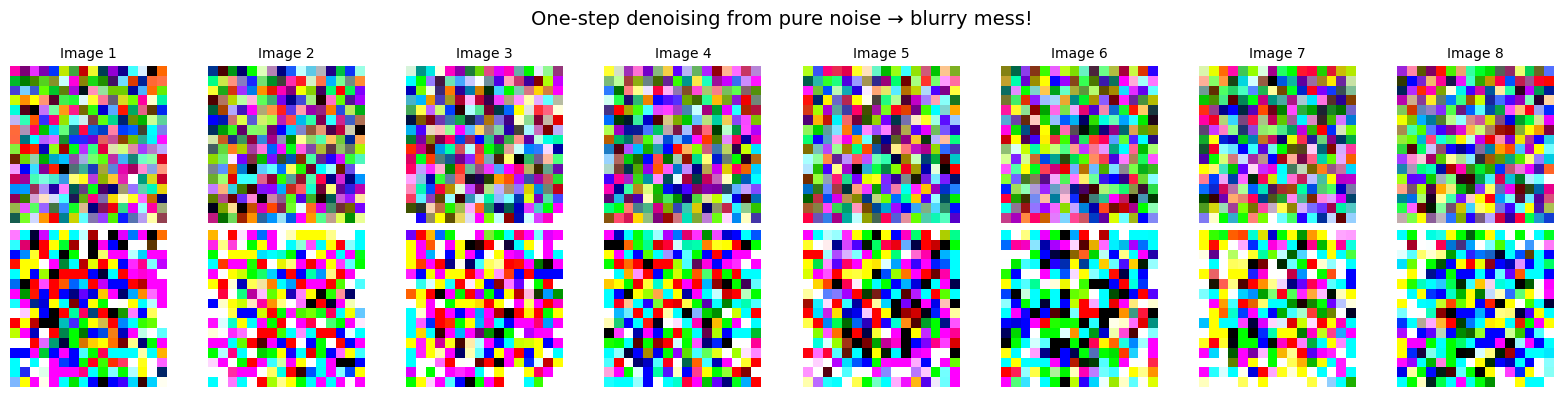

In [27]:

z_input, one_step_out = predict_one_shot(ema_model, n_samples=8)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    img_noise = z_input[i].cpu().clamp(-1, 1).permute(1, 2, 0) * 0.5 + 0.5
    axes[0, i].imshow(img_noise.numpy().clip(0, 1), interpolation="nearest")
    axes[0, i].set_title(f"Image {i+1}", fontsize=10)
    axes[0, i].axis("off")
    img_out = one_step_out[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    axes[1, i].imshow(img_out.numpy().clip(0, 1), interpolation="nearest")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Input\n(noise)", fontsize=11)
axes[1, 0].set_ylabel("Output\n(1 step)", fontsize=11)
plt.suptitle("One-step denoising from pure noise → blurry mess!", fontsize=14)
plt.tight_layout()
plt.show()

We get some noisy images: the reason is that many $x_0$ give the same $x_t$. Starting from $x_t$, the network learns to produce ONE output, which will be a average
over all seen $x_0$ for that $x_t$.

Instead, we break it into **small steps**:
* predict the added noise, this gives us $x_0$ using the closed-form formula (as before)
* compute the distribution of $x_{t-1}$, given that we known $x_t$ and $x_0$ (it is a Gaussian)
* use them to sample some $x_{t-1}$.

In formulas:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

where $$\sigma_t = \sqrt{\tilde{\beta}_t} \qquad \text{and}\qquad\tilde{\beta}_t = \dfrac{(1 - \bar{\alpha}_{t-1}) }{ (1 - \bar{\alpha}_t)} \beta_t$$ is the exact posterior standard deviation, and $z \sim \mathcal{N}(0, I)$ for $t > 1$, $z = 0$ for $t = 1$.

In [28]:
@torch.no_grad()
def ddpm_sample(model, n_samples=16, 
                capture_every=None, t_steps=T_STEPS):
    """Generate images using the DDPM sampling loop.

    Args:
        model: trained noise-prediction U-Net
        n_samples: number of images to generate
        capture_every: if set, capture intermediate snapshots every N steps.
                       Returns list of (timestep, image) tuples for the first sample.

    Returns:
        - Default: tensor of generated images (n_samples, C, H, W)
        - capture_every set: (samples, snapshots) where snapshots is a list of (t, img)
    """
    model.eval()
    z = torch.randn(n_samples, IMG_CHANNELS, IMG_SIZE, IMG_SIZE, device=device)


    # Multi-step DDPM sampling
    x = z.clone()
    snapshots = [(t_steps, x[0].cpu().clone())] if capture_every else None

    for t in tqdm(reversed(range(t_steps)), total=t_steps, desc="Sampling"):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch).sample

        alpha_t = alphas[t]
        alpha_bar_t = alpha_bar[t]
        beta_t = betas[t]

        mean = (1 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_pred
        )

        if t > 0:
            alpha_bar_prev = alpha_bar[t - 1]
            beta_tilde = ((1 - alpha_bar_prev) / (1 - alpha_bar_t)) * beta_t
            sigma = torch.sqrt(beta_tilde)
            x = mean + sigma * torch.randn_like(x)
        else:
            x = mean

        if capture_every:
            steps_done = t_steps - t
            if steps_done % capture_every == 0 or t == 0:
                snapshots.append((t, x[0].cpu().clone()))
    samples = x.clamp(-1, 1)
    if capture_every:
        return samples, snapshots
    return samples


### Visualising the generation process step by step

Let's watch a single image emerge from pure noise. We capture snapshots at regular
intervals during the reverse process.

Sampling: 100%|██████████| 1000/1000 [00:12<00:00, 80.82it/s]


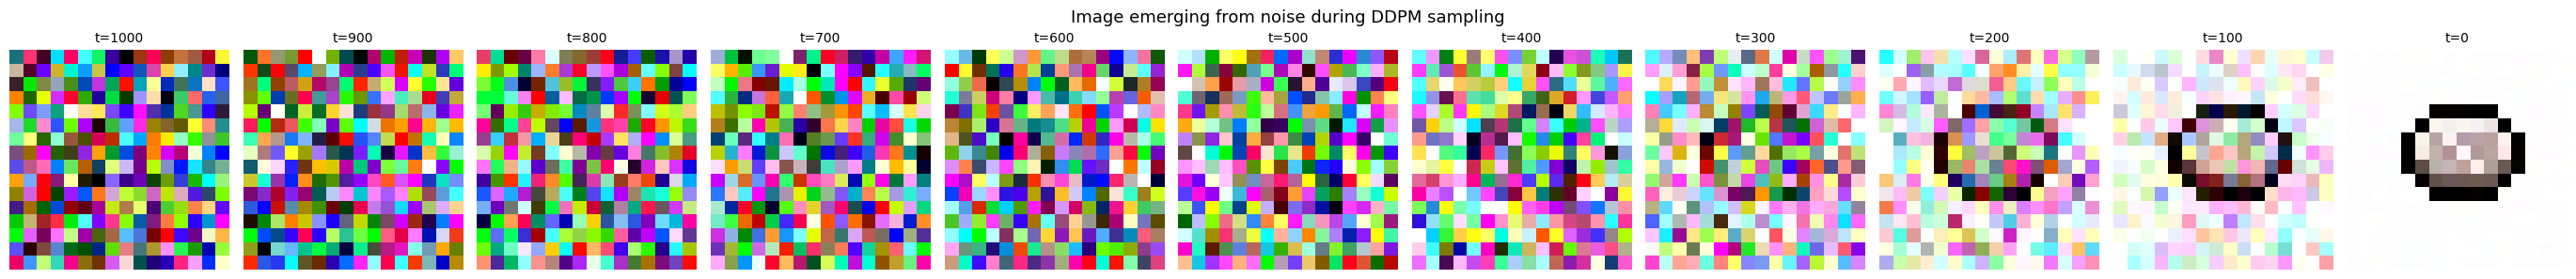

In [29]:
_, snapshots = ddpm_sample(ema_model, n_samples=1, capture_every=T_STEPS // 10)

fig, axes = plt.subplots(1, len(snapshots), figsize=(2.5 * len(snapshots), 3))
for ax, (t, img) in zip(axes, snapshots):
    img_show = img.permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img_show.numpy().clip(0, 1), interpolation="nearest")
    ax.set_title(f"t={t}", fontsize=10)
    ax.axis("off")
plt.suptitle("Image emerging from noise during DDPM sampling", fontsize=13)
plt.tight_layout()
plt.show()

Sampling: 100%|██████████| 1000/1000 [00:14<00:00, 66.68it/s]


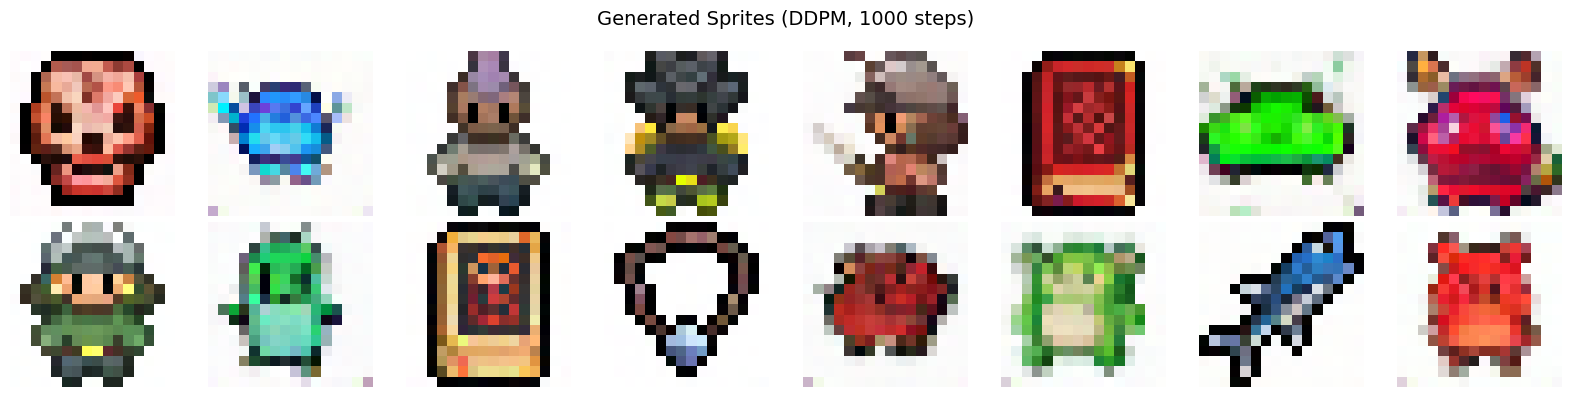

In [30]:
T_STEPS_SAMPLE = 1000

samples = ddpm_sample(ema_model, n_samples=16, t_steps=T_STEPS_SAMPLE)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = samples[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img.numpy().clip(0, 1), interpolation="nearest")
    ax.axis("off")
plt.suptitle("Generated Sprites (DDPM, 1000 steps)", fontsize=14)
plt.tight_layout()
plt.show()

### DDIM Sampling

**DDIM** (Denoising Diffusion Implicit Models, Song et al. 2020) is a deterministic
alternative to DDPM sampling that uses a **different update formula**: we compute $x_0$ from $\epsilon$ and we re-apply corruption to get $x_i$ for an arbitrary step $i$.

$$x_{i} = \sqrt{\bar\alpha_{i}} \cdot \underbrace{\frac{x_t - \sqrt{1-\bar\alpha_t}\,\epsilon_\theta}{\sqrt{\bar\alpha_t}}}_{\text{predicted } x_0} + \sqrt{1-\bar\alpha_{i}} \cdot \epsilon_\theta$$

Faster because we can skip some steps, but images may be blurry


In [31]:
@torch.no_grad()
def ddim_sample(model, n_samples=16, img_size=16, channels=3,
                ddim_steps=50, capture_every=None):
    """Generate images using DDIM (deterministic) sampling.

    Unlike DDPM, DDIM can use far fewer steps (e.g. 50 instead of 1000)
    because it predicts x_0 at each step and re-noises to the target level.

    Args:
        model: trained noise-prediction U-Net
        n_samples: number of images to generate
        img_size: spatial resolution
        channels: number of image channels
        ddim_steps: number of sampling steps (can be much less than T_STEPS)
        capture_every: if set, capture snapshots every N steps
    """
    model.eval()

    # Select a subset of timesteps evenly spaced from [0, T_STEPS)
    step_size = T_STEPS // ddim_steps
    timesteps = list(range(0, T_STEPS, step_size))  # e.g. [0, 20, 40, ...]
    timesteps = list(reversed(timesteps))  # go from high noise to low

    x = torch.randn(n_samples, channels, img_size, img_size, device=device)
    snapshots = [(T_STEPS, x[0].cpu().clone())] if capture_every else None

    for i, t in enumerate(tqdm(timesteps, desc=f"DDIM ({ddim_steps} steps)")):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)
        eps_pred = model(x, t_batch).sample

        alpha_bar_t = alpha_bar[t]

        # Predict x_0 from current x_t and predicted noise
        x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * eps_pred) / torch.sqrt(alpha_bar_t)
        x0_pred = x0_pred.clamp(-1, 1)

        if i < len(timesteps) - 1:
            # Next timestep in our schedule
            t_next = timesteps[i + 1]
            alpha_bar_next = alpha_bar[t_next]

            # DDIM update: re-noise x0_pred to the level of t_next
            # using the same predicted noise direction (no randomness)
            x = (torch.sqrt(alpha_bar_next) * x0_pred +
                 torch.sqrt(1 - alpha_bar_next) * eps_pred)
        else:
            # Last step: just use the predicted x_0
            x = x0_pred

        if capture_every and (i % capture_every == 0 or i == len(timesteps) - 1):
            snapshots.append((t, x[0].cpu().clone()))

    samples = x.clamp(-1, 1)
    if capture_every:
        return samples, snapshots
    return samples

DDIM (50 steps): 100%|██████████| 50/50 [00:00<00:00, 57.86it/s]


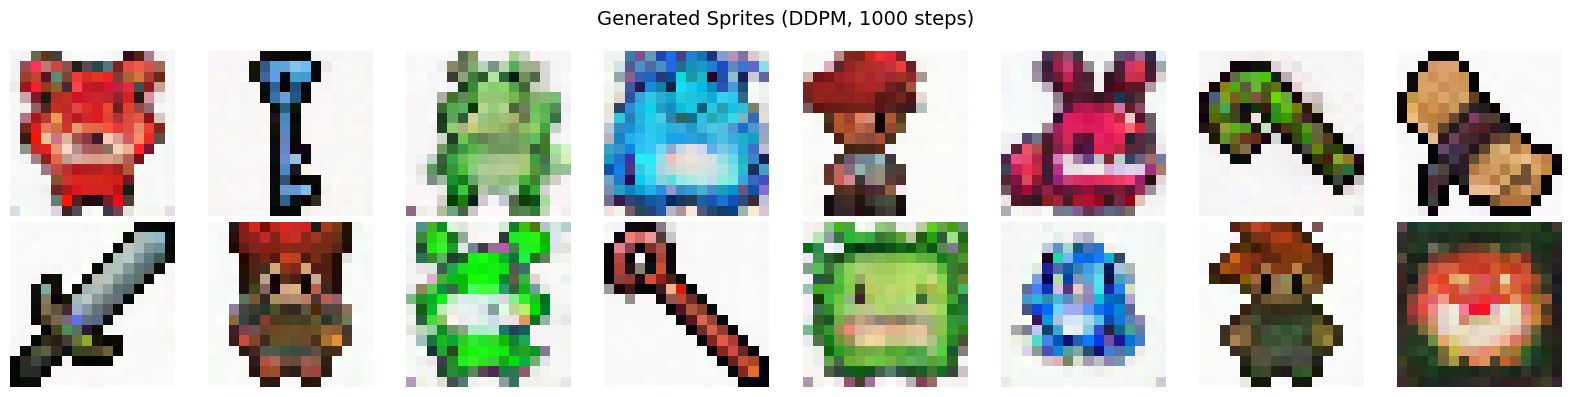

In [32]:
ddim_imgs = ddim_sample(model, n_samples=16, ddim_steps=50)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = ddim_imgs[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img.numpy().clip(0, 1), interpolation="nearest")
    ax.axis("off")
plt.suptitle("Generated Sprites (DDPM, 1000 steps)", fontsize=14)
plt.tight_layout()
plt.show()


---
### Exercises
1. What happens if you change T_STEPS_SAMPLE? What happens if you change the nr of steps in the DDIM sampling?
2. Cosine schedule: replace the linear schedule with a cosine schedule
    and compare results
3. What happens if you change $\sigma$ in DDPM sampling?